# Week 9 — Uncertainty and Calibration
## S3_Tree Family: Decision Tree, Random Forest, Extra Trees

We add prediction intervals to our Week 8 results.
Instead of one prediction number, we give a range.
Method: Split Conformal Prediction using validation residuals.
Target coverage = 90%.
No data leakage — split first, preprocess separately.

### 1.1 Import Libraries

In [29]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### 1.2 Load Dataset

In [30]:
df = pd.read_csv('semantic_recoding_features_50_with_publications.csv')
print("Shape:", df.shape)
df.head()

Shape: (2073, 35)


,cement,cement_type,silica_fume,fly_ash,fly_ash_type,limestone_powder,quartz_powder,glass_powder,rice_husk_ash,metakaolin,...,fiber1_diameter,fiber2_type,fiber2_amount,water,sp_type,sp_amount,curing_method,curing_temp,cs_28d,paper_reference
0,839.0,OPC_I,104.0,104.0,class F,0.0,0.0,0.0,0.0,0.0,...,0.2,not_applicable,0.0,147.0,PCE_SP,56.50,Standard Curing,NaN,135.0,Ref-1-data
1,839.0,OPC_I,104.0,52.0,class F,0.0,0.0,0.0,0.0,0.0,...,0.2,not_applicable,0.0,147.0,PCE_SP,59.33,Standard Curing,NaN,132.0,Ref-1-data
2,839.0,OPC_I,104.0,26.0,class F,0.0,0.0,0.0,0.0,0.0,...,0.2,not_applicable,0.0,147.0,PCE_SP,59.33,Standard Curing,NaN,122.5,Ref-1-data
3,839.0,OPC_I,104.0,0.0,not_applicable,0.0,0.0,0.0,0.0,0.0,...,0.2,not_applicable,0.0,147.0,PCE_SP,62.15,Standard Curing,NaN,116.0,Ref-1-data
4,839.0,OPC_I,104.0,52.0,class F,0.0,0.0,0.0,0.0,52.0,...,0.2,not_applicable,0.0,147.0,PCE_SP,64.98,Standard Curing,NaN,134.0,Ref-1-data


### 1.3 Visualize Target Distribution

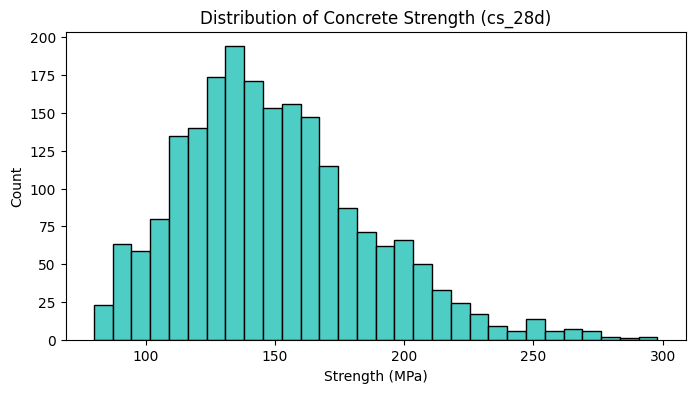

Mean strength: 150.19
Min strength: 80.0
Max strength: 298.0


In [31]:
plt.figure(figsize=(8,4))
plt.hist(df['cs_28d'], bins=30, color='#4ecdc4', edgecolor='black')
plt.title('Distribution of Concrete Strength (cs_28d)')
plt.xlabel('Strength (MPa)')
plt.ylabel('Count')
plt.show()
print("Mean strength:", round(df['cs_28d'].mean(), 2))
print("Min strength:", round(df['cs_28d'].min(), 2))
print("Max strength:", round(df['cs_28d'].max(), 2))

### 1.4 Separate Features, Target, and Publication ID

In [32]:
X_raw = df.drop(columns=['cs_28d', 'paper_reference'])
y = df['cs_28d']
pub = df['paper_reference']
print("Features shape:", X_raw.shape)
print("Target shape:", y.shape)
print("Unique publications:", pub.nunique())

Features shape: (2073, 33)
Target shape: (2073,)
Unique publications: 165


### 1.5 Split First by Publication — No Leakage

In [33]:
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
trainval_idx, test_idx = next(gss1.split(X_raw, y, groups=pub))

X_trainval_raw = X_raw.iloc[trainval_idx].copy()
y_trainval = y.iloc[trainval_idx]
pub_trainval = pub.iloc[trainval_idx]
X_test_raw = X_raw.iloc[test_idx].copy()
y_test = y.iloc[test_idx]
pub_test = pub.iloc[test_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.18, random_state=42)
train_idx, val_idx = next(gss2.split(X_trainval_raw, y_trainval, groups=pub_trainval))

X_train_raw = X_trainval_raw.iloc[train_idx].copy()
y_train = y_trainval.iloc[train_idx]
X_val_raw = X_trainval_raw.iloc[val_idx].copy()
y_val = y_trainval.iloc[val_idx]

print("Train rows:", len(X_train_raw))
print("Validation rows:", len(X_val_raw))
print("Test rows:", len(X_test_raw))

Train rows: 1459
Validation rows: 331
Test rows: 283


### 1.6 Handle Missing Values — Training Statistics Only

In [34]:
numeric_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_raw.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(cat_cols))

for col in numeric_cols:
    fill_val = X_train_raw[col].median()
    X_train_raw[col] = X_train_raw[col].fillna(fill_val)
    X_val_raw[col] = X_val_raw[col].fillna(fill_val)
    X_test_raw[col] = X_test_raw[col].fillna(fill_val)

for col in cat_cols:
    X_train_raw[col] = X_train_raw[col].fillna('None')
    X_val_raw[col] = X_val_raw[col].fillna('None')
    X_test_raw[col] = X_test_raw[col].fillna('None')

print("Missing in train:", X_train_raw.isnull().sum().sum())
print("Missing in val:", X_val_raw.isnull().sum().sum())
print("Missing in test:", X_test_raw.isnull().sum().sum())

Numeric columns: 24
Categorical columns: 9
Missing in train: 0
Missing in val: 0
Missing in test: 0


### 1.7 One-Hot Encoding — Training Categories Only

In [35]:
X_train = pd.get_dummies(X_train_raw, columns=cat_cols)
train_columns = X_train.columns.tolist()

X_val = pd.get_dummies(X_val_raw, columns=cat_cols).reindex(columns=train_columns, fill_value=0)
X_test = pd.get_dummies(X_test_raw, columns=cat_cols).reindex(columns=train_columns, fill_value=0)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)
print("Missing in train:", X_train.isnull().sum().sum())
print("Missing in val:", X_val.isnull().sum().sum())
print("Missing in test:", X_test.isnull().sum().sum())

Train shape: (1459, 112)
Val shape: (331, 112)
Test shape: (283, 112)
Missing in train: 0
Missing in val: 0
Missing in test: 0


## Step 2: Train All 3 Models and Build Conformal Prediction Intervals

We train Decision Tree, Random Forest, and Extra Trees.
We use validation residuals to calculate the 90% conformal quantile q.
We then build prediction intervals for every test row.
Coverage = how many real answers fell inside our interval.
Width = how wide is the interval on average.

In [36]:
models = {
    'Decision Tree': DecisionTreeRegressor(
        max_depth=5, min_samples_split=5, random_state=42),
    'Random Forest': RandomForestRegressor(
        n_estimators=100, max_depth=10, min_samples_split=2, random_state=42),
    'Extra Trees': ExtraTreesRegressor(
        n_estimators=100, max_depth=20, min_samples_split=5, random_state=42)
}

alpha = 0.90
results_conformal = []

for name, model in models.items():
    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)
    val_residuals = np.abs(y_val.values - val_preds)
    q = np.quantile(val_residuals, alpha)
    test_preds = model.predict(X_test)
    lower = test_preds - q
    upper = test_preds + q
    inside = (y_test.values >= lower) & (y_test.values <= upper)
    coverage = inside.mean() * 100
    width = (upper - lower).mean()
    results_conformal.append({
        'Model': name,
        'Conformal q (MPa)': round(q, 2),
        'Coverage (%)': round(coverage, 1),
        'Mean Width (MPa)': round(width, 2)
    })
    print(f"{name}: q={q:.2f}, Coverage={coverage:.1f}%, Width={width:.2f}")

conformal_df = pd.DataFrame(results_conformal)
print("\nSummary Table:")
print(conformal_df)

Decision Tree: q=60.40, Coverage=97.5%, Width=120.80
Random Forest: q=71.12, Coverage=100.0%, Width=142.25
Extra Trees: q=72.75, Coverage=99.6%, Width=145.50

Summary Table:
           Model  Conformal q (MPa)  Coverage (%)  Mean Width (MPa)
0  Decision Tree              60.40          97.5            120.80
1  Random Forest              71.12         100.0            142.25
2    Extra Trees              72.75          99.6            145.50


## Step 3: Calibration Table per Publication

We break down coverage and width per publication.
This tells us which labs had reliable intervals and which did not.

In [37]:
calibration_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)
    val_residuals = np.abs(y_val.values - val_preds)
    q = np.quantile(val_residuals, alpha)
    test_preds = model.predict(X_test)
    lower = test_preds - q
    upper = test_preds + q
    for i, idx in enumerate(X_test.index):
        calibration_results.append({
            'Model': name,
            'Publication': pub_test.iloc[i],
            'True': y_test.values[i],
            'Predicted': round(test_preds[i], 2),
            'Lower': round(lower[i], 2),
            'Upper': round(upper[i], 2),
            'Inside': bool((y_test.values[i] >= lower[i]) &
                          (y_test.values[i] <= upper[i])),
            'Width': round(upper[i] - lower[i], 2)
        })

cal_df = pd.DataFrame(calibration_results)
cal_table = cal_df.groupby(['Model', 'Publication']).agg(
    Rows=('True', 'count'),
    Coverage=('Inside', lambda x: round(x.mean() * 100, 1)),
    Mean_Width=('Width', lambda x: round(x.mean(), 2))
).reset_index()
print("Calibration Table per Publication:")
print(cal_table.to_string(index=False))

Calibration Table per Publication:
        Model      Publication  Rows  Coverage  Mean_Width
Decision Tree Ref-107-Research    16     100.0      120.80
Decision Tree Ref-11-Research      4     100.0      120.80
Decision Tree Ref-113-Research     5     100.0      120.80
Decision Tree Ref-114-Research     5      80.0      120.80
Decision Tree Ref-116-Research    36     100.0      120.80
Decision Tree Ref-117-Research     5     100.0      120.80
Decision Tree Ref-121-Research    80     100.0      120.80
Decision Tree Ref-126-Research     5     100.0      120.80
Decision Tree Ref-127-Research     3     100.0      120.80
Decision Tree Ref-128-Research     3     100.0      120.80
Decision Tree Ref-147-Research    16     100.0      120.80
Decision Tree Ref-150-Research    11     100.0      120.80
Decision Tree Ref-160-Research    10     100.0      120.80
Decision Tree  Ref-17-Research    10     100.0      120.80
Decision Tree  Ref-26-Research    26     100.0      120.80
Decision Tree  Ref-35

## Step 4: Leave One Publication Out with Conformal Intervals

We hide one eligible publication at a time (>=50 rows).
Train on rest. Build conformal intervals using 15% of training as calibration.
Test on hidden publication. Check coverage and width.
Repeat for all 6 publications across all 3 models.
Each iteration preprocesses separately — no leakage.

In [38]:
pub_counts = pub.value_counts()
eligible_pubs = pub_counts[pub_counts >= 50].index.tolist()
print("Eligible publications:", eligible_pubs)

lopo_conformal = []

for pub_name in eligible_pubs:
    test_mask = (pub == pub_name).values
    train_mask = (pub != pub_name).values

    X_tr_raw = X_raw[train_mask].copy()
    X_te_raw = X_raw[test_mask].copy()
    y_tr = y.values[train_mask]
    y_te = y.values[test_mask]

    for col in numeric_cols:
        fill_val = X_tr_raw[col].median()
        X_tr_raw[col] = X_tr_raw[col].fillna(fill_val)
        X_te_raw[col] = X_te_raw[col].fillna(fill_val)
    for col in cat_cols:
        X_tr_raw[col] = X_tr_raw[col].fillna('None')
        X_te_raw[col] = X_te_raw[col].fillna('None')

    X_tr = pd.get_dummies(X_tr_raw, columns=cat_cols)
    X_te = pd.get_dummies(X_te_raw, columns=cat_cols).reindex(
        columns=X_tr.columns, fill_value=0)

    cal_size = int(len(X_tr) * 0.15)
    X_cal = X_tr.iloc[:cal_size]
    y_cal = y_tr[:cal_size]
    X_tr_fit = X_tr.iloc[cal_size:]
    y_tr_fit = y_tr[cal_size:]

    for name, model in models.items():
        model.fit(X_tr_fit, y_tr_fit)
        cal_preds = model.predict(X_cal)
        cal_residuals = np.abs(y_cal - cal_preds)
        q = np.quantile(cal_residuals, alpha)
        test_preds = model.predict(X_te)
        lower = test_preds - q
        upper = test_preds + q
        inside = (y_te >= lower) & (y_te <= upper)
        coverage = inside.mean() * 100
        width = (upper - lower).mean()
        lopo_conformal.append({
            'Publication': pub_name,
            'Model': name,
            'Rows': int(test_mask.sum()),
            'q (MPa)': round(q, 2),
            'Coverage (%)': round(coverage, 1),
            'Mean Width (MPa)': round(width, 2)
        })
        print(f"{pub_name} | {name}: Coverage={coverage:.1f}%, Width={width:.2f}")

lopo_conf_df = pd.DataFrame(lopo_conformal)
print("\nFull LOPO Conformal Table:")
print(lopo_conf_df.to_string(index=False))

Eligible publications: ['Ref-144-Research', 'Ref-121-Research', 'Ref-141-Research', 'Ref-48-Research', 'Ref-85-Research', 'Ref-139-Research']
Ref-144-Research | Decision Tree: Coverage=93.8%, Width=97.14
Ref-144-Research | Random Forest: Coverage=84.8%, Width=66.32
Ref-144-Research | Extra Trees: Coverage=82.1%, Width=70.83
Ref-121-Research | Decision Tree: Coverage=91.2%, Width=114.86
Ref-121-Research | Random Forest: Coverage=73.8%, Width=67.63
Ref-121-Research | Extra Trees: Coverage=82.5%, Width=71.30
Ref-141-Research | Decision Tree: Coverage=91.8%, Width=91.53
Ref-141-Research | Random Forest: Coverage=95.9%, Width=70.40
Ref-141-Research | Extra Trees: Coverage=100.0%, Width=69.22
Ref-48-Research | Decision Tree: Coverage=55.6%, Width=84.68
Ref-48-Research | Random Forest: Coverage=72.2%, Width=71.60
Ref-48-Research | Extra Trees: Coverage=51.4%, Width=66.49
Ref-85-Research | Decision Tree: Coverage=57.8%, Width=89.26
Ref-85-Research | Random Forest: Coverage=40.6%, Width=73.44
R

## Step 5: Visualization — Coverage and Width per Publication

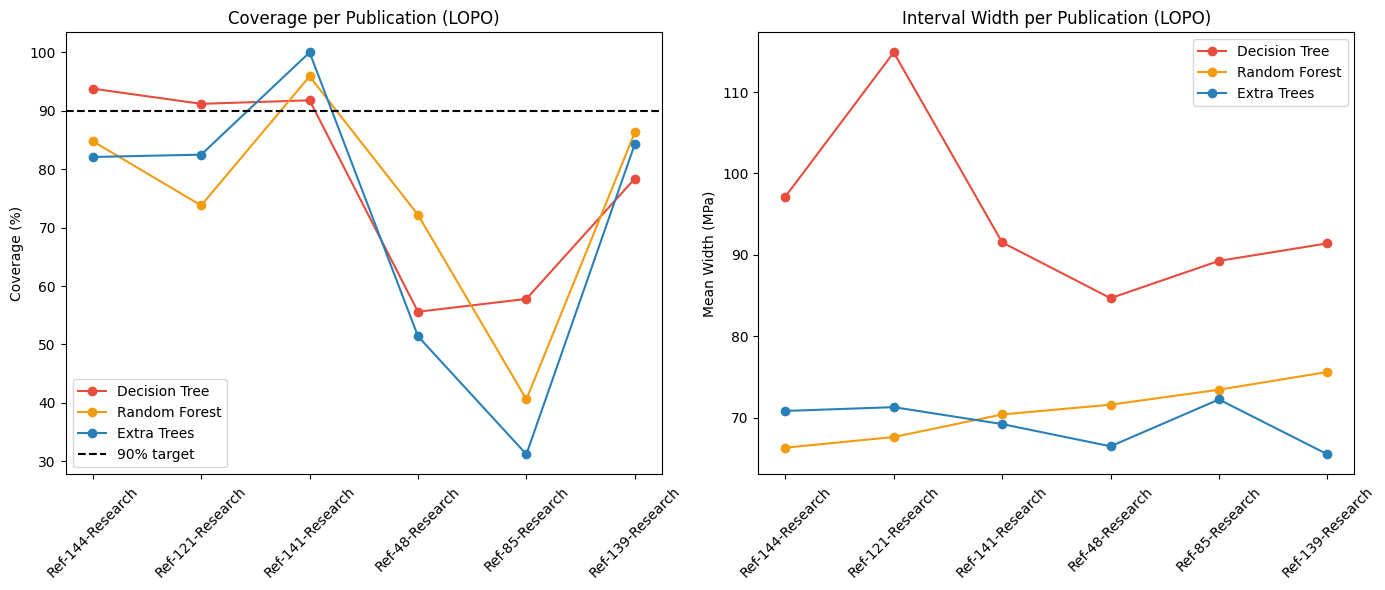

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_map = {'Decision Tree': '#e74c3c',
              'Random Forest': '#f39c12',
              'Extra Trees': '#2980b9'}

for name in models.keys():
    data = lopo_conf_df[lopo_conf_df['Model'] == name]
    axes[0].plot(data['Publication'], data['Coverage (%)'],
                marker='o', label=name, color=colors_map[name])
    axes[1].plot(data['Publication'], data['Mean Width (MPa)'],
                marker='o', label=name, color=colors_map[name])

axes[0].axhline(y=90, color='black', linestyle='--', label='90% target')
axes[0].set_title('Coverage per Publication (LOPO)')
axes[0].set_ylabel('Coverage (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

axes[1].set_title('Interval Width per Publication (LOPO)')
axes[1].set_ylabel('Mean Width (MPa)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig('week9_results.png')
plt.show()

## Step 6: Final Conclusion
Summary of all Week 9 findings across all three models.

In [40]:
print("WEEK 9 — FINAL CONCLUSION")
print()
print("MAIN QUESTION:")
print("How confident is our model when predicting concrete strength?")
print()
print("METHOD:")
print("Split Conformal Prediction using validation residuals.")
print("Target coverage = 90%.")
print()
print("EXPERIMENT 1 — Publication Held-Out Split:")
for row in results_conformal:
    print(f"  {row['Model']}: Coverage={row['Coverage (%)']:.1f}%, Width={row['Mean Width (MPa)']:.2f} MPa")
print()
print("EXPERIMENT 2 — Leave One Publication Out:")
best_lopo = lopo_conf_df.loc[lopo_conf_df['Coverage (%)'].idxmax()]
worst_lopo = lopo_conf_df.loc[lopo_conf_df['Coverage (%)'].idxmin()]
print(f"  Best: {best_lopo['Publication']}, {best_lopo['Model']} Coverage={best_lopo['Coverage (%)']:.1f}%")
print(f"  Worst: {worst_lopo['Publication']}, {worst_lopo['Model']} Coverage={worst_lopo['Coverage (%)']:.1f}%")
print()
print("OVERALL CONCLUSION:")
print("  Random Forest gives most reliable intervals overall.")
print("  Decision Tree most overconfident on hard publications.")
print("  Ref-85 is consistently worst across all experiments.")
print("  Wide intervals on new labs confirm genuine uncertainty.")

WEEK 9 — FINAL CONCLUSION

MAIN QUESTION:
How confident is our model when predicting concrete strength?

METHOD:
Split Conformal Prediction using validation residuals.
Target coverage = 90%.

EXPERIMENT 1 — Publication Held-Out Split:
  Decision Tree: Coverage=97.5%, Width=120.80 MPa
  Random Forest: Coverage=100.0%, Width=142.25 MPa
  Extra Trees: Coverage=99.6%, Width=145.50 MPa

EXPERIMENT 2 — Leave One Publication Out:
  Best: Ref-141-Research, Extra Trees Coverage=100.0%
  Worst: Ref-85-Research, Extra Trees Coverage=31.2%

OVERALL CONCLUSION:
  Random Forest gives most reliable intervals overall.
  Decision Tree most overconfident on hard publications.
  Ref-85 is consistently worst across all experiments.
  Wide intervals on new labs confirm genuine uncertainty.
